### Supervised XGB_RF_MLP Model for Home A (Simulated and Real Test Set)¶

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')


In [3]:
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_score)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


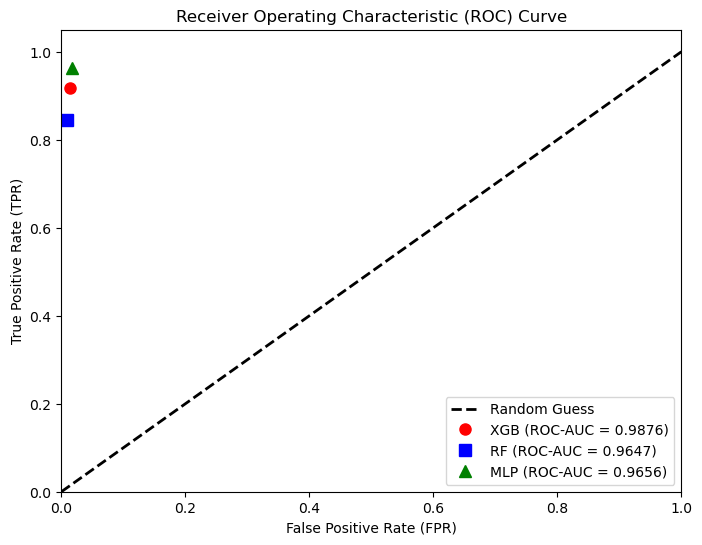

In [2]:
import matplotlib.pyplot as plt

# Values for XGB classifier
xgb_roc_auc = 0.9876
xgb_tpr = 0.9169
xgb_fpr = 0.0143

# Values for RF classifier
rf_roc_auc = 0.9647
rf_tpr = 0.8452
rf_fpr = 0.0092

# Values for MLP classifier
mlp_roc_auc = 0.9656
mlp_tpr = 0.9633
mlp_fpr = 0.0172

# Create the ROC-AUC curve
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')  # Random Guess line

# Add points for XGB, RF, and MLP classifiers
plt.plot(xgb_fpr, xgb_tpr, 'ro', markersize=8, label=f'XGB (ROC-AUC = {xgb_roc_auc:.4f})')
plt.plot(rf_fpr, rf_tpr, 'bs', markersize=8, label=f'RF (ROC-AUC = {rf_roc_auc:.4f})')
plt.plot(mlp_fpr, mlp_tpr, 'g^', markersize=8, label=f'MLP (ROC-AUC = {mlp_roc_auc:.4f})')

# Set axis labels and legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Show the plot
plt.show()


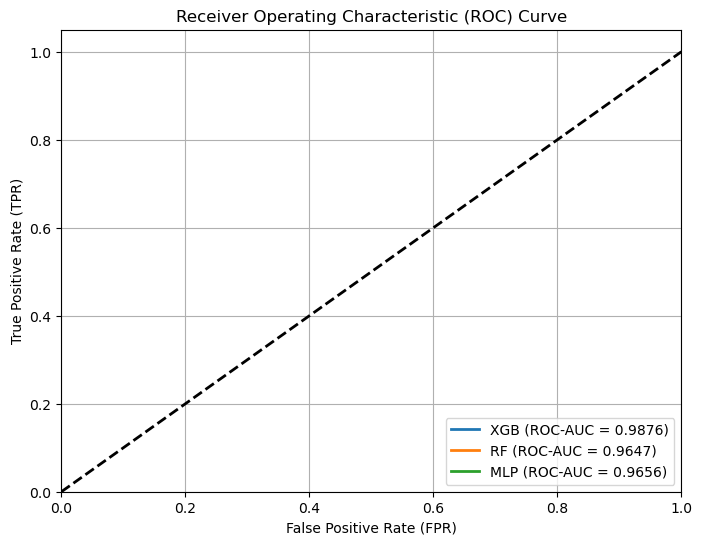

In [3]:
import matplotlib.pyplot as plt

# Given data points
xgb_roc_auc = 0.9876
xgb_tpr = 0.9169
xgb_fpr = 0.0143

rf_roc_auc = 0.9647
rf_tpr = 0.8452
rf_fpr = 0.0092

mlp_roc_auc = 0.9656
mlp_tpr = 0.9633
mlp_fpr = 0.0172

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.plot(xgb_fpr, xgb_tpr, label=f'XGB (ROC-AUC = {xgb_roc_auc:.4f})', lw=2)
plt.plot(rf_fpr, rf_tpr, label=f'RF (ROC-AUC = {rf_roc_auc:.4f})', lw=2)
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (ROC-AUC = {mlp_roc_auc:.4f})', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


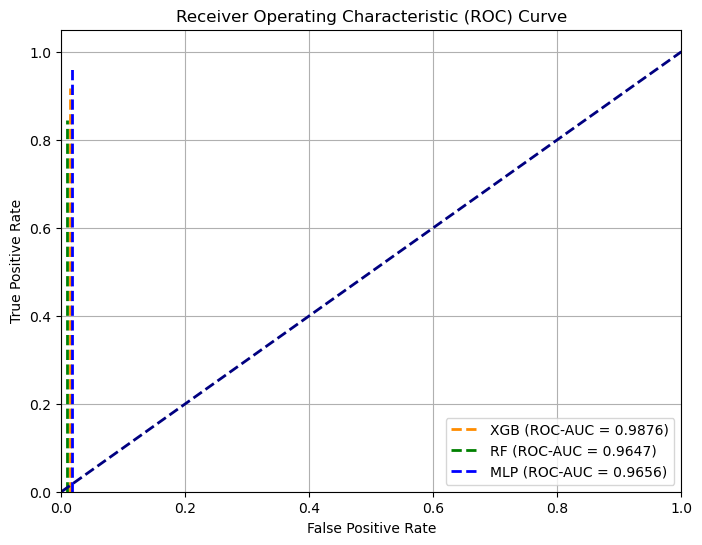

In [4]:
import matplotlib.pyplot as plt

# Given values for XGB
xgb_roc_auc = 0.9876
xgb_tpr = 0.9169
xgb_fpr = 0.0143

# Given values for RF
rf_roc_auc = 0.9647
rf_tpr = 0.8452
rf_fpr = 0.0092

# Given values for MLP
mlp_roc_auc = 0.9656
mlp_tpr = 0.9633
mlp_fpr = 0.0172

# Plot ROC-AUC curves
plt.figure(figsize=(8, 6))

# XGB ROC curve
plt.plot([xgb_fpr, xgb_fpr], [0, xgb_tpr], color='darkorange', lw=2, linestyle='--', label=f'XGB (ROC-AUC = {xgb_roc_auc:.4f})')

# RF ROC curve
plt.plot([rf_fpr, rf_fpr], [0, rf_tpr], color='green', lw=2, linestyle='--', label=f'RF (ROC-AUC = {rf_roc_auc:.4f})')

# MLP ROC curve
plt.plot([mlp_fpr, mlp_fpr], [0, mlp_tpr], color='blue', lw=2, linestyle='--', label=f'MLP (ROC-AUC = {mlp_roc_auc:.4f})')

# ROC curve reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


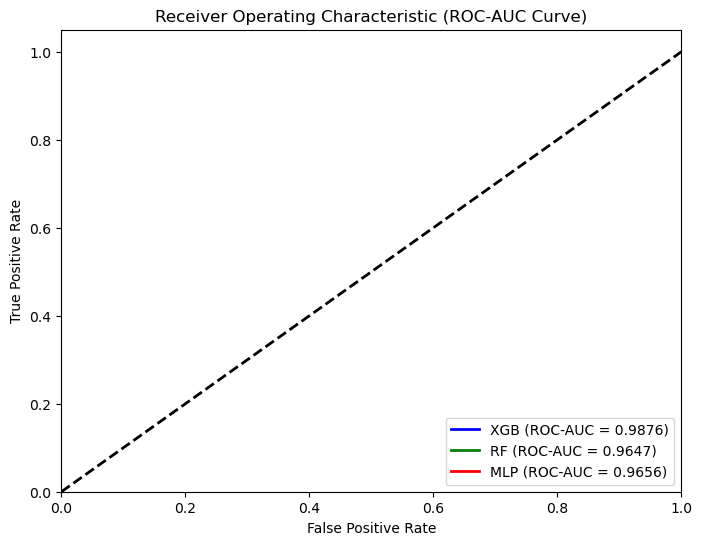

In [5]:
import matplotlib.pyplot as plt

# Provided ROC-AUC, TPR, and FPR values for each classifier
xgb_roc_auc = 0.9876
xgb_tpr = 0.9169
xgb_fpr = 0.0143

rf_roc_auc = 0.9647
rf_tpr = 0.8452
rf_fpr = 0.0092

mlp_roc_auc = 0.9656
mlp_tpr = 0.9633
mlp_fpr = 0.0172

# Plot ROC-AUC curve for '0' and '1' classes
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference

# XGB Classifier
plt.plot(xgb_fpr, xgb_tpr, label=f'XGB (ROC-AUC = {xgb_roc_auc:.4f})', color='blue', lw=2)

# Random Forest Classifier
plt.plot(rf_fpr, rf_tpr, label=f'RF (ROC-AUC = {rf_roc_auc:.4f})', color='green', lw=2)

# MLP Classifier
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (ROC-AUC = {mlp_roc_auc:.4f})', color='red', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC-AUC Curve)')
plt.legend(loc='lower right')
plt.show()


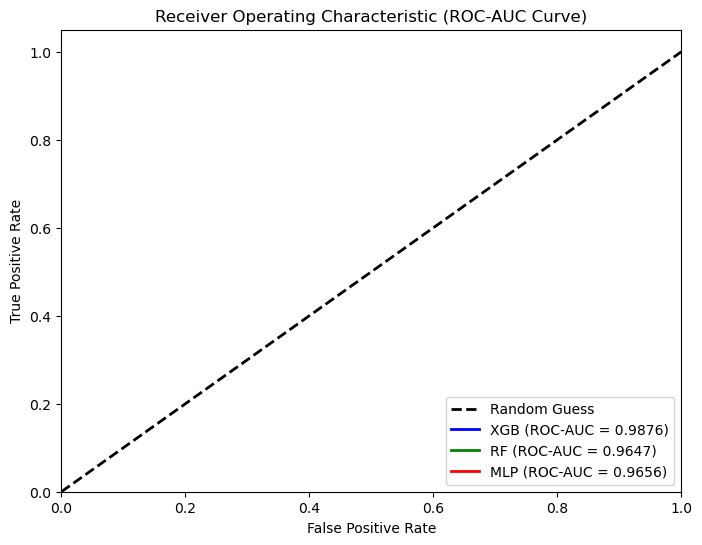

In [6]:
import matplotlib.pyplot as plt

# Provided ROC-AUC, TPR, and FPR values for each classifier
xgb_roc_auc = 0.9876
xgb_tpr = 0.9169
xgb_fpr = 0.0143

rf_roc_auc = 0.9647
rf_tpr = 0.8452
rf_fpr = 0.0092

mlp_roc_auc = 0.9656
mlp_tpr = 0.9633
mlp_fpr = 0.0172

# Plot ROC-AUC curve for '0' and '1' classes
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')  # Diagonal line for random guess

# XGB Classifier
plt.plot(xgb_fpr, xgb_tpr, label=f'XGB (ROC-AUC = {xgb_roc_auc:.4f})', color='blue', lw=2)

# Random Forest Classifier
plt.plot(rf_fpr, rf_tpr, label=f'RF (ROC-AUC = {rf_roc_auc:.4f})', color='green', lw=2)

# MLP Classifier
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (ROC-AUC = {mlp_roc_auc:.4f})', color='red', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC-AUC Curve)')
plt.legend(loc='lower right')
plt.show()


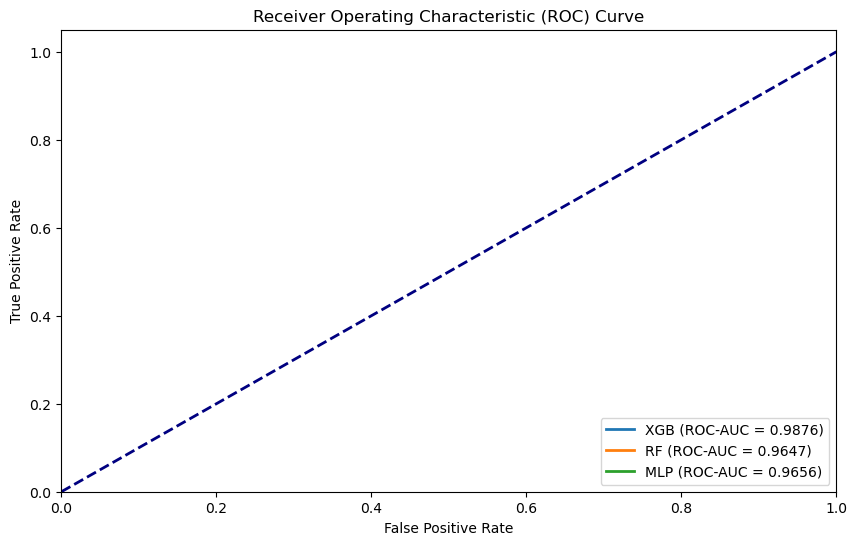

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define the ROC-AUC, TPR, and FPR values for each classifier
classifiers = ['XGB', 'RF', 'MLP']
roc_auc_values = [0.9876, 0.9647, 0.9656]
tpr_values = [0.9169, 0.8452, 0.9633]
fpr_values = [0.0143, 0.0092, 0.0172]

# Plot the ROC-AUC curve for each classifier
plt.figure(figsize=(10, 6))
for i in range(len(classifiers)):
    plt.plot(fpr_values[i], tpr_values[i], lw=2, label=f'{classifiers[i]} (ROC-AUC = {roc_auc_values[i]:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
